In [28]:
import re
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

print(f"PyTorch versão {torch.__version__} importado com sucesso!")

# Definindo o dispositivo (Usa GPU se disponível, senão CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo de processamento: {device}")

if device == 'cuda':
    torch.cuda.empty_cache()

PyTorch versão 2.11.0+cu126 importado com sucesso!
Dispositivo de processamento: cuda


In [29]:
df = pd.read_csv('hateBR.csv', sep=',', usecols=['comentario', 'label_final' ])

X = df['comentario'].values
y = df['label_final'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Tamanho do treino: {len(X_train)} amostras")
print(f"Tamanho do teste: {len(X_test)} amostras")

Tamanho do treino: 5250 amostras
Tamanho do teste: 1750 amostras


In [30]:
MAX_LEN = 15 # Tamanho maximo da frase

# 1. Construindo o vocabulário a partir dos dados de treino
todas_as_palavras = [palavra for frase in X_train for palavra in frase.lower().split()]
frequencia_palavras = Counter(todas_as_palavras)

# Mapeando palavras para indices. Reservamos 0 para Padding e 1 para Unknown (OOV)
vocabulario = {palavra: idx + 2 for idx, (palavra, _) in enumerate(frequencia_palavras.most_common())}
vocabulario['<PAD>'] = 0
vocabulario['<UNK>'] = 1

# Dicionário reverso para facilitar a visualização da Atenção depois
inv_vocab = {idx: palavra for palavra, idx in vocabulario.items()}

# Removendo virgulas
def limpar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'[^\w\s]', '', texto)
    return texto

# Função par converter texto em sequencia de numeros com padding
def texto_para_sequencia(texto, vocab, max_len):
    tokens = limpar_texto(texto).split()
    #tokens = texto.lower().split()
    seq = [vocab.get(token, vocab['<UNK>']) for token in tokens]
    
    # Padding (preenchimento com zeros) ou truncamento (corte)
    if len(seq) < max_len:
        seq = seq + [vocab['<PAD>' ]] * (max_len - len(seq))
    else:
        seq = seq[:max_len]
    return seq

# 2. Criando a classe Dataset do PyTorch
class TextoDataset(Dataset):
    def __init__(self, X, y, vocab, max_len):
        self.X = [texto_para_sequencia(texto, vocab, max_len) for texto in X]
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # Retorna a sequencia como tensor de inteiros e a label como tensor float
        return torch.tensor(self.X[idx], dtype=torch. long), torch.tensor(self.y[idx], dtype=torch.float32)

# Instanciando Datasets e DataLoaders (para gerar batches)
# Alteração: batch_size aumentado de 2 para 32 para otimizar o treinamento
train_dataset = TextoDataset(X_train, y_train, vocabulario, MAX_LEN)
test_dataset = TextoDataset(X_test, y_test, vocabulario, MAX_LEN)

# batch_size:
# 32 original
# 24
train_loader = DataLoader(train_dataset, batch_size=24, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=24, shuffle=False, pin_memory=True)

print("Tamanho do Vocabulário:", len(vocabulario))

Tamanho do Vocabulário: 15734


In [31]:
class CamadaAtencao(nn.Module):
    def __init__(self, hidden_dim):
        super(CamadaAtencao, self).__init__()
        self.calculo_score = nn.Linear(hidden_dim, 1)

    def forward(self, lstm_outputs):
        # lstm_outputs shape: (batch_size, seq_length, hidden_dim)
        scores = self.calculo_score(lstm_outputs) # (batch, seq, 1)
        pesos_atencao = F.softmax(scores, dim=1)

        vetores_ponderados = lstm_outputs * pesos_atencao
        vetor_contexto = torch. sum(vetores_ponderados, dim=1) # (batch, hidden_dim)

        return vetor_contexto, pesos_atencao

class ModeloHateSpeechAttention(nn.Module):
    def __init__(self, tamanho_vocab, dimensao_embedding, dimensao_oculta):
        super(ModeloHateSpeechAttention, self).__init__()

        self.embedding = nn.Embedding(tamanho_vocab, dimensao_embedding, padding_idx=0)
        
        # Adicionando Bidirecionalidade para capturar contexto do futuro para o passado também
        self.lstm = nn.LSTM(dimensao_embedding, dimensao_oculta, batch_first=True, bidirectional=True)

        # Como é bidirecional, a dimensão de saída da LSTM dobra (oculta * 2)
        self.atencao = CamadaAtencao(dimensao_oculta * 2)

        self.dropout = nn.Dropout(0.3) # Dropout levemente aumentado

        self.fc = nn.Linear(dimensao_oculta * 2, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        # x shape: (batch_size, max_len)
        embedded = self.dropout(self.embedding(x))

        lstm_out, _= self.lstm(embedded)

        # Passamos as saídas de todos os tokens para a camada de atenção
        vetor_contexto, pesos_atencao = self.atencao(lstm_out)

        out = self.fc(self.dropout(vetor_contexto))
        out = self.sigmoid(out)

        # squeeze(-1) é mais seguro que squeeze(), pois remove apenas a última dimensão de tamanho 1
        # Isso evita que o batch de tamanho 1 seja acidentalmente esmagado na inferência
        return out.squeeze(-1), pesos_atencao
    
# Instanciando o modelo
tamanho_vocab = len(vocabulario)
dim_embedding = 16
dim_oculta = 32

modelo = ModeloHateSpeechAttention(tamanho_vocab, dim_embedding, dim_oculta).to(device)
print(modelo)

ModeloHateSpeechAttention(
  (embedding): Embedding(15734, 16, padding_idx=0)
  (lstm): LSTM(16, 32, batch_first=True, bidirectional=True)
  (atencao): CamadaAtencao(
    (calculo_score): Linear(in_features=64, out_features=1, bias=True)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [32]:
criterio = nn.BCELoss()
# Reduzindo o learning rate para 0.005 para estabilizar a convergência do mecanismo de atenção
# lr:
# 0.005 original
otimizador = optim.Adam(modelo.parameters(), lr=0.005)

def calcular_acuracia(previsoes, labels):
    previsoes_arredondadas = torch.round(previsoes)
    corretas = (previsoes_arredondadas == labels).float()
    return corretas. sum() / len(corretas)

# Com o Attention e batch_size=32, 15 épocas costumam ser suficientes para este dataset
# 50
# 30 original
# 15
# 25
epocas = 25

for epoca in range(epocas):
    modelo.train()
    loss_treino = 0.0
    acc_treino = 0.0

    for textos, labels in train_loader:
        textos, labels = textos.to(device), labels.to(device)
        
        otimizador.zero_grad()

        # O modelo agora retorna a previsão e a matriz de atenção. Descartamos a atenção aqui (_).
        previsoes, _ = modelo(textos)

        loss = criterio(previsoes, labels)
        acc = calcular_acuracia(previsoes, labels)
        loss.backward()
        otimizador.step()

        loss_treino += loss.item()
        acc_treino += acc.item()
        
    loss_media = loss_treino / len(train_loader)
    acc_media = acc_treino / len(train_loader)

    print(f"Época {epoca+1:02d}/{epocas} | Loss: {loss_media:.4f} | Acurácia: {acc_media*100:.2f}%")

Época 01/25 | Loss: 0.6475 | Acurácia: 61.47%
Época 02/25 | Loss: 0.5209 | Acurácia: 73.55%
Época 03/25 | Loss: 0.4161 | Acurácia: 80.83%
Época 04/25 | Loss: 0.3480 | Acurácia: 84.30%
Época 05/25 | Loss: 0.2831 | Acurácia: 87.37%
Época 06/25 | Loss: 0.2397 | Acurácia: 90.07%
Época 07/25 | Loss: 0.2021 | Acurácia: 92.05%
Época 08/25 | Loss: 0.1758 | Acurácia: 92.88%
Época 09/25 | Loss: 0.1411 | Acurácia: 94.50%
Época 10/25 | Loss: 0.1328 | Acurácia: 94.77%
Época 11/25 | Loss: 0.1141 | Acurácia: 95.80%
Época 12/25 | Loss: 0.0996 | Acurácia: 96.20%
Época 13/25 | Loss: 0.0943 | Acurácia: 96.32%
Época 14/25 | Loss: 0.0848 | Acurácia: 96.80%
Época 15/25 | Loss: 0.0749 | Acurácia: 97.14%
Época 16/25 | Loss: 0.0682 | Acurácia: 97.41%
Época 17/25 | Loss: 0.0638 | Acurácia: 97.68%
Época 18/25 | Loss: 0.0632 | Acurácia: 97.69%
Época 19/25 | Loss: 0.0556 | Acurácia: 97.71%
Época 20/25 | Loss: 0.0585 | Acurácia: 97.92%
Época 21/25 | Loss: 0.0462 | Acurácia: 98.36%
Época 22/25 | Loss: 0.0427 | Acurá

In [33]:
modelo.eval()

loss_teste = 0.0
acc_teste = 0.0

with torch.no_grad():
    for textos, labels in test_loader:
        textos, labels = textos.to(device), labels.to(device)

        previsoes, _ = modelo(textos)
        loss = criterio(previsoes, labels)
        acc = calcular_acuracia(previsoes, labels)

        loss_teste += loss.item()
        acc_teste += acc.item()

loss_teste_media = loss_teste / len(test_loader)
acc_teste_media = acc_teste / len(test_loader)

print("-" * 30)
print(f"RESULTADOS NO CONJUNTO DE TESTE:")
print(f"Loss: {loss_teste_media:.4f}")
print(f"Acurácia: {acc_teste_media*100:.2f}%")
print("-" * 30)

------------------------------
RESULTADOS NO CONJUNTO DE TESTE:
Loss: 0.8787
Acurácia: 83.23%
------------------------------



Frase original: 'que dia excelente para estudar programação'
Predição Bruta: 0.0097 -> TEXTO NORMAL/NEUTRO


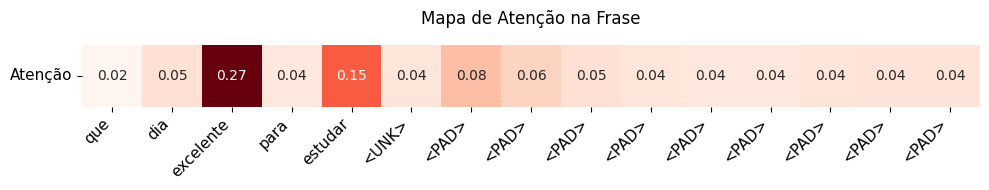


Frase original: 'eu odeio quando acaba a luz'
Predição Bruta: 0.0022 -> TEXTO NORMAL/NEUTRO


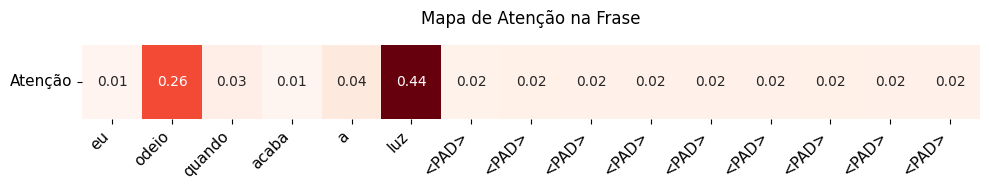


Frase original: 'eu odeio pessoas assim, do seu partido, voces sao todos uns idiotas lixo'
Predição Bruta: 1.0000 -> DISCURSO DE ÓDIO DETECTADO !!! 


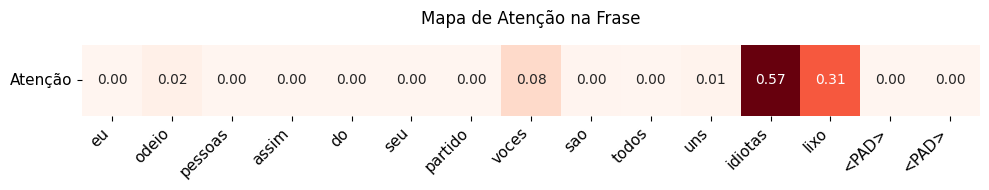


Frase original: 'meu dia fica péssimo quando esqueço o guarda chuva'
Predição Bruta: 0.0001 -> TEXTO NORMAL/NEUTRO


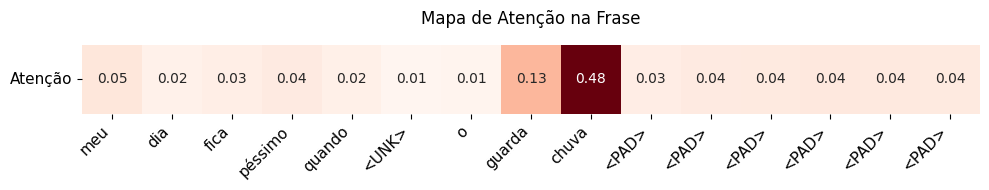

In [34]:
def plotar_mapa_atencao(tokens, pesos_atencao):
    pesos = pesos_atencao.cpu().numpy().squeeze()

    plt.figure(figsize=(10, 2))
    sns.heatmap([pesos],
                xticklabels=tokens,
                yticklabels=['Atenção'],
                cmap='Reds',
                annot=True,
                fmt=".2f",
                cbar=False)

    plt.title("Mapa de Atenção na Frase", pad=15)
    plt.xticks(rotation=45, ha='right', fontsize=11)
    plt.yticks(rotation=0, fontsize=11)
    plt.tight_layout()
    plt.show()
    
def detectar_odio_com_atencao(frase, modelo, vocab, inv_vocab):
    modelo.eval()
    seq = texto_para_sequencia(frase, vocab, MAX_LEN)
    tensor_entrada = torch.tensor([seq], dtype=torch. long).to(device)

    with torch.no_grad():
        predicao, pesos_atencao = modelo(tensor_entrada)
        predicao_valor = predicao.item()

    if predicao_valor > 0.5:
        resultado = "DISCURSO DE ÓDIO DETECTADO !!! "
    else:
        resultado = "TEXTO NORMAL/NEUTRO"

    print(f"\nFrase original: '{frase}'")
    print(f"Predição Bruta: {predicao_valor:.4f} -> {resultado}")

    # Reconstruir os tokens originais para o plot a partir do padding
    tokens_reais = [inv_vocab.get(idx, '<UNK>') for idx in seq]
    
    plotar_mapa_atencao(tokens_reais, pesos_atencao[0])
    
# Testes
frases_teste = [
    "que dia excelente para estudar programação",
    "eu odeio quando acaba a luz",
    "eu odeio pessoas assim, do seu partido, voces sao todos uns idiotas lixo",
    "meu dia fica péssimo quando esqueço o guarda chuva"
]

for frase in frases_teste:
    detectar_odio_com_atencao(frase, modelo, vocabulario, inv_vocab)